# Implementacion

# Librerias

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, RocCurveDisplay,classification_report,roc_auc_score
)
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression


In [2]:
import warnings
warnings.filterwarnings("ignore")

# Cargado de datos

In [3]:
df=pd.read_csv('processed.cleveland.data',na_values='?')

In [4]:
df.head()

,63.0,1.0,1.0.1,145.0,233.0,1.0.2,2.0,150.0,0.0,2.3,3.0,0.0.1,6.0,0
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


In [5]:
#Añadimos los nombres de las columnas 
df.columns = ["edad", "sexo", "dolor_toracico", "presion_reposo", "colesterol",
            "azucar_en_sangre", "electrocardiograma", "frecuencia_max", 
            "angina", "oldpeak", "pendiente", "vessel", "thal", "target"]

In [6]:
df.head()

,edad,sexo,dolor_toracico,presion_reposo,colesterol,azucar_en_sangre,electrocardiograma,frecuencia_max,angina,oldpeak,pendiente,vessel,thal,target
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


# Funciones

In [7]:
def Summary(data, sheet):
    print(f"Hoja: {sheet}")

    # Crear la tabla de resumen
    resumen = {
        "Cantidad de filas": data.shape[0],
        "Cantidad de columnas": data.shape[1],
        "Datos faltantes": data.isnull().sum().sum(),
        "Filas duplicadas": data.duplicated().sum()
    }

    # Convertir el resumen en un DataFrame
    ResumenHoja = pd.DataFrame(resumen, index=["Resumen"])
    print("\nResumen:")
    display(ResumenHoja)

    print("\nEncabezado:")
    display(data.head())

In [8]:
def graficar_distribuciones(df, columnas, bins=30):
    sns.set(style="whitegrid", palette="muted")
    n = len(columnas)
    
    fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 4*n))
    
    for i, col in enumerate(columnas):
        # Histograma con KDE
        sns.histplot(data=df, x=col, kde=True, bins=bins, ax=axes[i,0], color="skyblue")
        axes[i,0].set_title(f"Histograma de {col}", fontsize=12)
        axes[i,0].set_xlabel("")
        axes[i,0].set_ylabel("Frecuencia")
        
        # Boxplot
        sns.boxplot(data=df, x=col, ax=axes[i,1], color="lightcoral")
        axes[i,1].set_title(f"Boxplot de {col}", fontsize=12)
        axes[i,1].set_xlabel("")
    
    plt.suptitle("Distribuciones de variables numéricas", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Analisis exploratorio de datos

In [9]:
Summary(df,'Datos pacientes')

Hoja: Datos pacientes

Resumen:


,Cantidad de filas,Cantidad de columnas,Datos faltantes,Filas duplicadas
Resumen,302,14,6,0



Encabezado:


,edad,sexo,dolor_toracico,presion_reposo,colesterol,azucar_en_sangre,electrocardiograma,frecuencia_max,angina,oldpeak,pendiente,vessel,thal,target
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


Podemos observar que hay algunos valores faltantes presentes en estos datos 

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   edad                302 non-null    float64
 1   sexo                302 non-null    float64
 2   dolor_toracico      302 non-null    float64
 3   presion_reposo      302 non-null    float64
 4   colesterol          302 non-null    float64
 5   azucar_en_sangre    302 non-null    float64
 6   electrocardiograma  302 non-null    float64
 7   frecuencia_max      302 non-null    float64
 8   angina              302 non-null    float64
 9   oldpeak             302 non-null    float64
 10  pendiente           302 non-null    float64
 11  vessel              298 non-null    float64
 12  thal                300 non-null    float64
 13  target              302 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.2 KB


Podemos observar que se toman como numericas algunas variables que los numeros representan categorias, estas se van a transformar a categoricas 

In [11]:
categoricas=['sexo','dolor_toracico','azucar_en_sangre','electrocardiograma','angina','pendiente','thal']
df[categoricas]=df[categoricas].astype(object)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   edad                302 non-null    float64
 1   sexo                302 non-null    object 
 2   dolor_toracico      302 non-null    object 
 3   presion_reposo      302 non-null    float64
 4   colesterol          302 non-null    float64
 5   azucar_en_sangre    302 non-null    object 
 6   electrocardiograma  302 non-null    object 
 7   frecuencia_max      302 non-null    float64
 8   angina              302 non-null    object 
 9   oldpeak             302 non-null    float64
 10  pendiente           302 non-null    object 
 11  vessel              298 non-null    float64
 12  thal                300 non-null    object 
 13  target              302 non-null    int64  
dtypes: float64(6), int64(1), object(7)
memory usage: 33.2+ KB


## Analisis Univariado

Realizamos el analisis univariado de cada una de las variables del dataset, empezando por las variables numericas

In [13]:
numericas = ['edad', 'presion_reposo', 'colesterol', 'frecuencia_max', 'oldpeak','vessel']

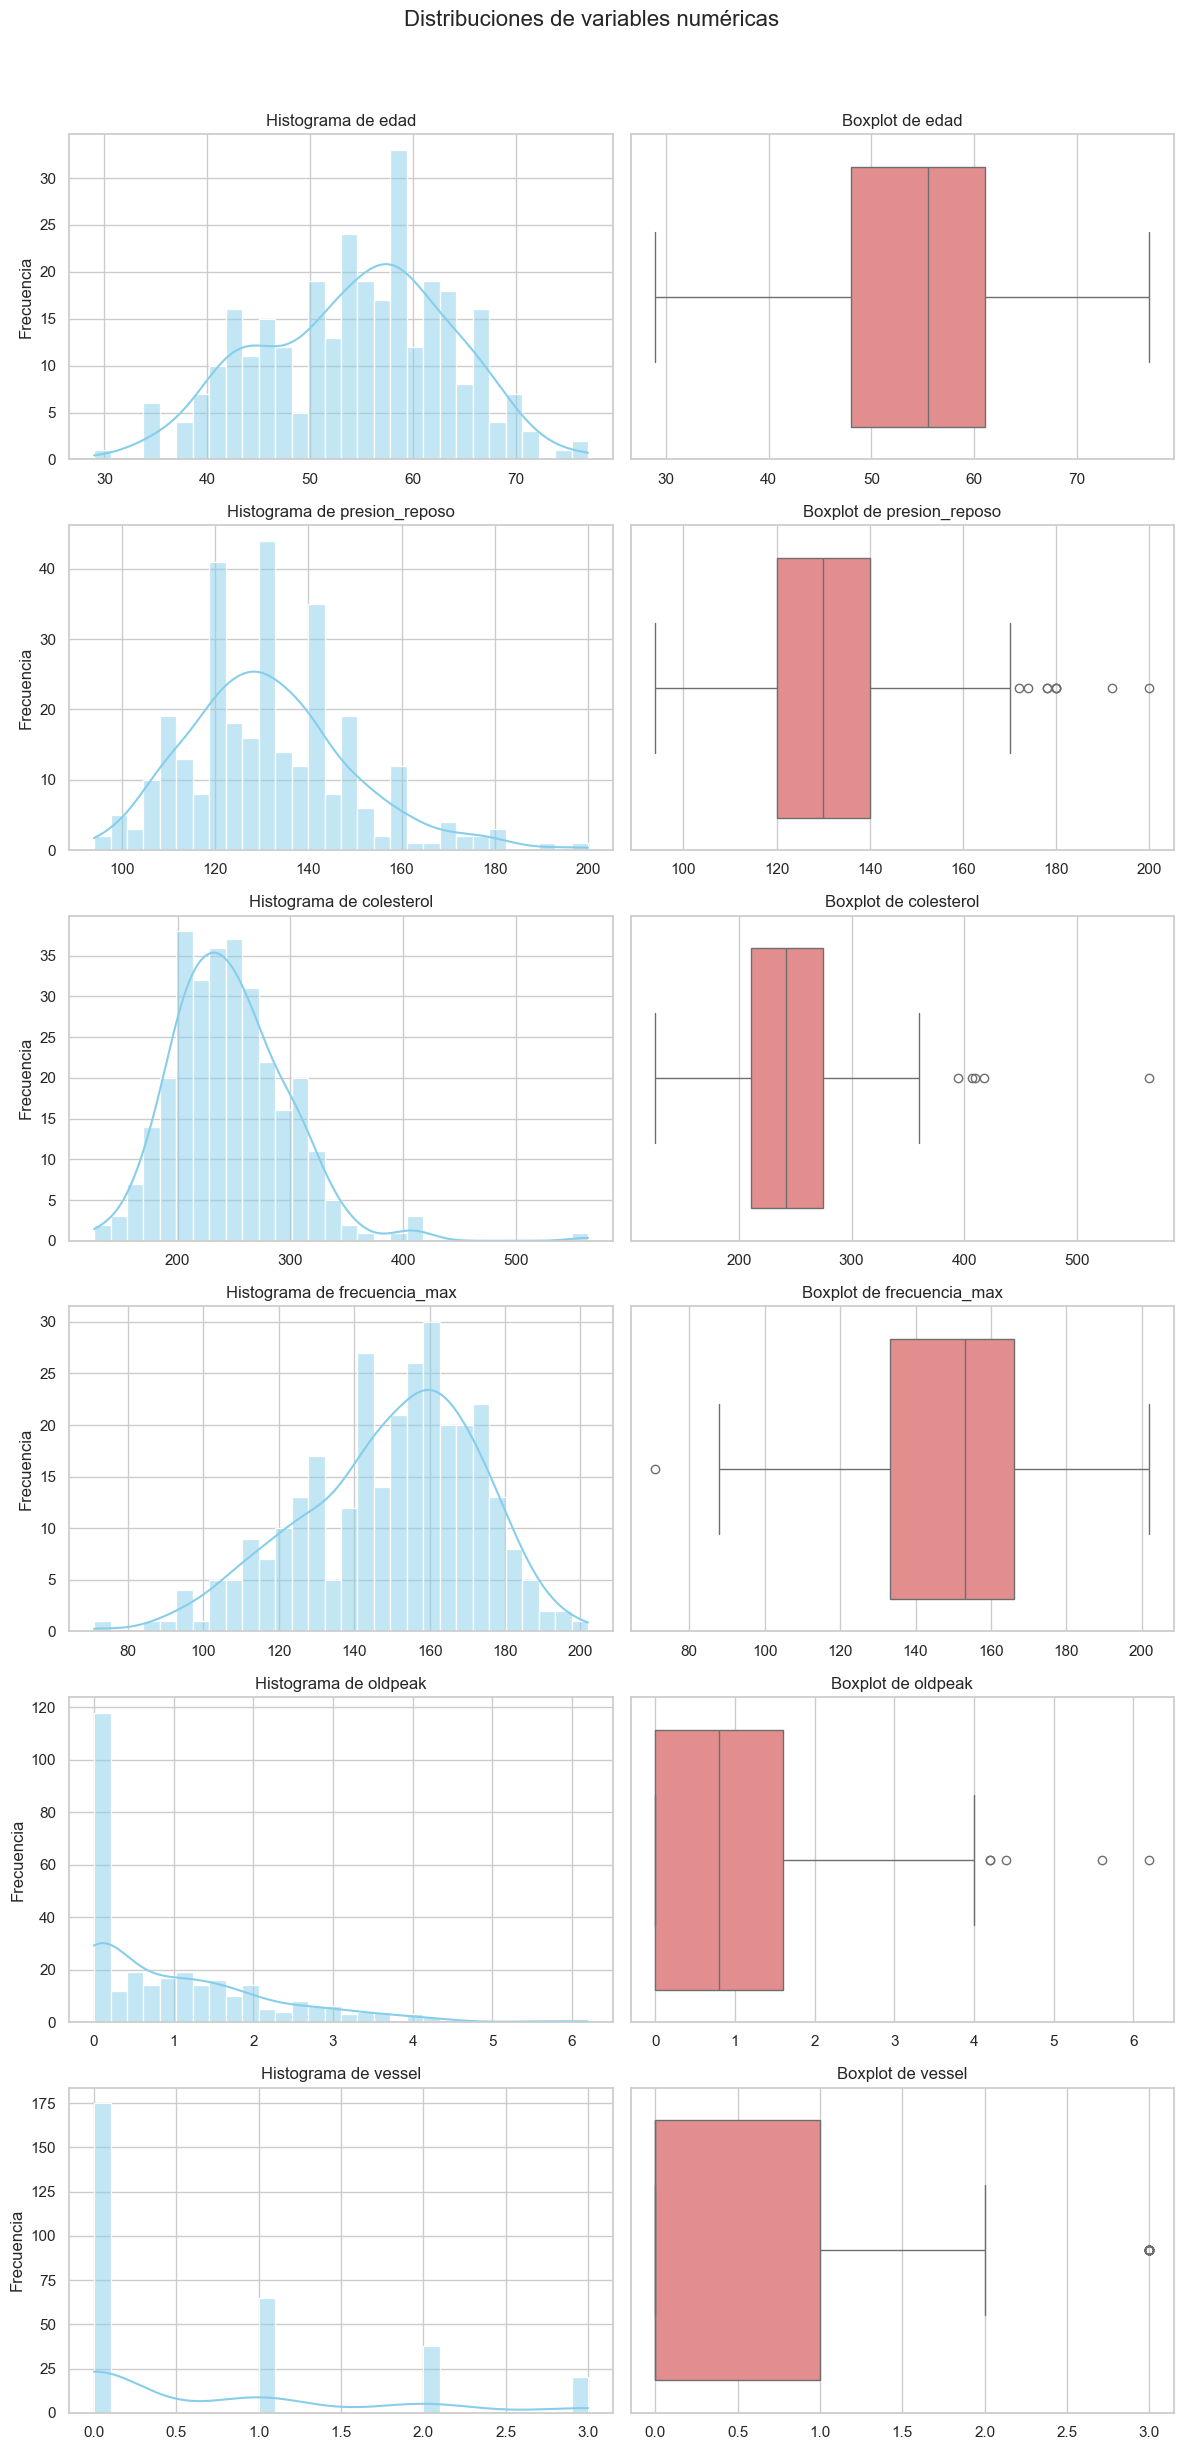

In [14]:
graficar_distribuciones(df,numericas)

Podemos observar que algunas de las variables tienen datos atipicos, Principalmente de las variables de oldpeak,presion_reposo y colesterol, sin embargo estos outliers son importantes datos a tomar en cuenta para el modelo por lo que no se deben tratar. 

Analizamos las variables categoricas

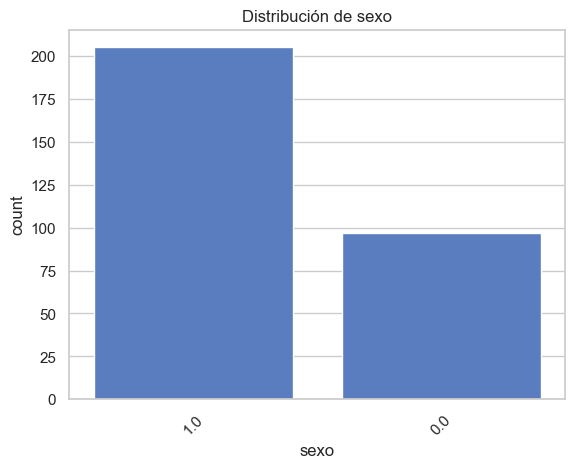

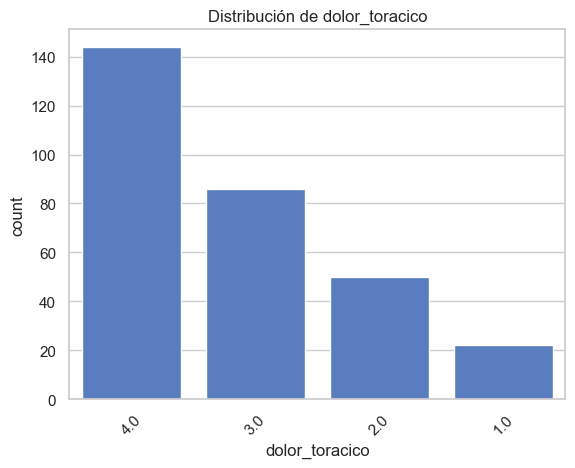

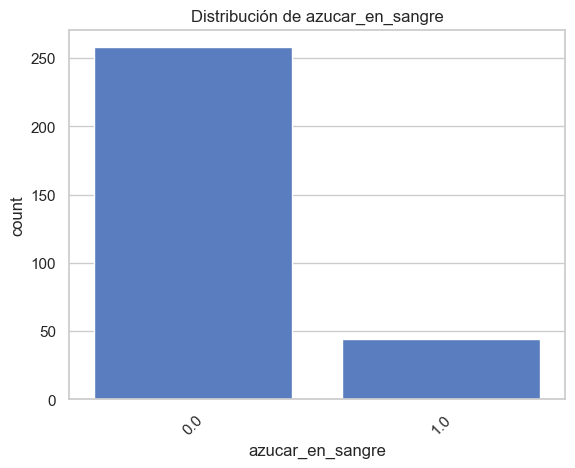

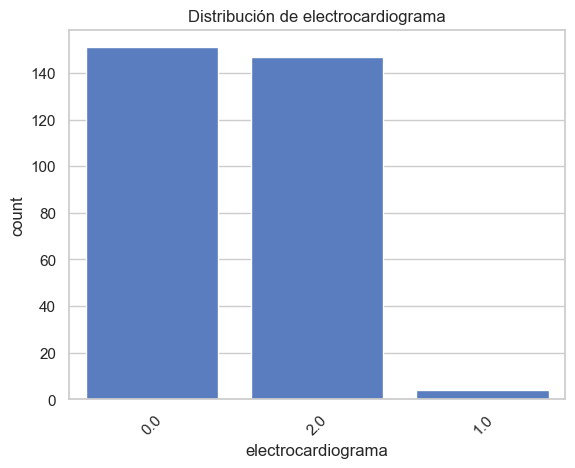

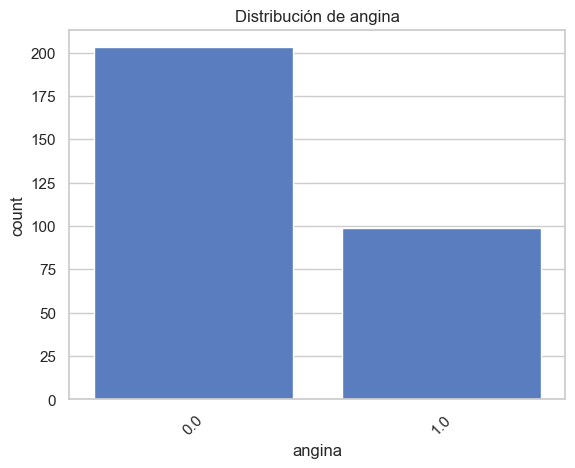

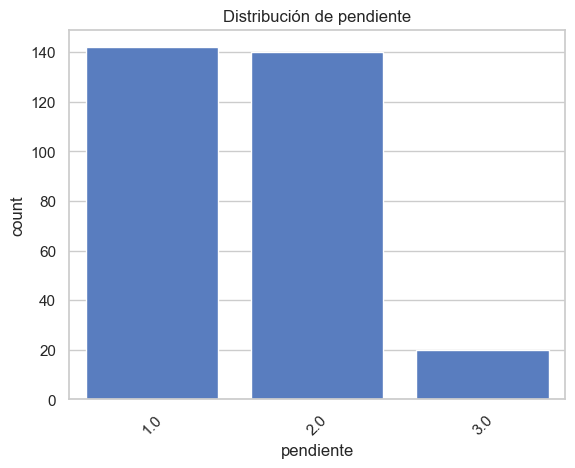

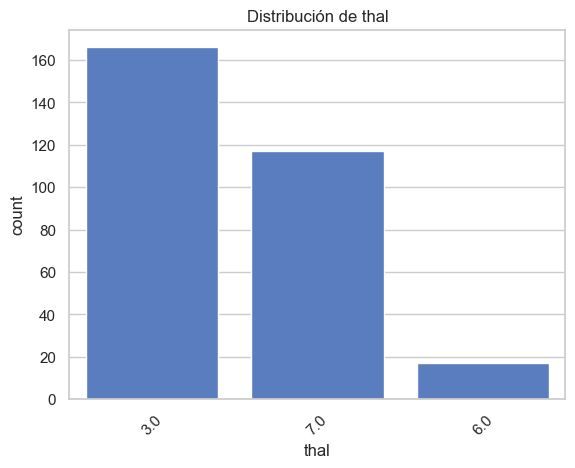

In [15]:
for col in categoricas:
    df[col].value_counts()
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)
    plt.show()

Analizamos la distribucion de la variable target

In [16]:
df['target'].value_counts()

target
0    163
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Podemos observar que la variable target no esta en formato binario sino que esta en una escala entre 0 y 4 con 0 siendo ausencia de enfermedad, se va a convertir target a binaria para poder utilizarla despues en el modelo

In [17]:
df['target'] = df['target'].apply(lambda x: 0 if x == 0 else 1)

In [18]:
df['target'].value_counts()

target
0    163
1    139
Name: count, dtype: int64

In [19]:
sns.set_style('whitegrid')

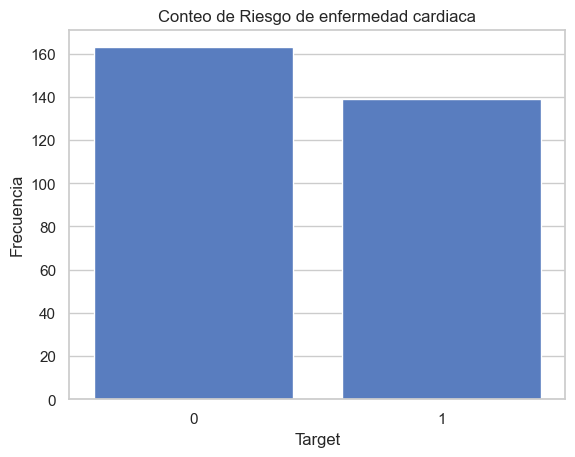

In [20]:
plt.title('Conteo de Riesgo de enfermedad cardiaca')
sns.countplot(x=df.target)
plt.xlabel('Target')
plt.ylabel('Frecuencia')
plt.show()

Podemos observar que no existe una gran diferencia entre las categorias 0 y 1 de la variable target, por lo tanto podemos decir que el dataset esta relativamente balanceado

Se revisan el numero de datos faltantes asi como su porcentaje 

In [21]:
total=df.isna().sum()
print('Numero de faltantes: \n', total)

Numero de faltantes: 
 edad                  0
sexo                  0
dolor_toracico        0
presion_reposo        0
colesterol            0
azucar_en_sangre      0
electrocardiograma    0
frecuencia_max        0
angina                0
oldpeak               0
pendiente             0
vessel                4
thal                  2
target                0
dtype: int64


Podemos observar que el porcentaje de datos faltantes es muy bajo, se realizara imputacion simple para abarcarlos dentro del pipeline 

# Preprocesamiento de datos

## Creacion de pipelines

Se crean los pipelines para el preprocesamiento de datos

In [22]:
#Pipeline Categorico
Pipe_cat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))
])

In [23]:
#pipeline numerico
Pipe_num=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()) 
    ])

In [24]:
#Preprocesamiento mediante column transformer 
preprocesador = ColumnTransformer(
    transformers=[
        ('num', Pipe_num, numericas),
        ('cat', Pipe_cat, categoricas)
    ]
)

Creamos el pipeline principal

In [25]:
#Pipeline Principal con preprocesamiento y modelo
Pipe = Pipeline(steps=[
    ('preprocesador', preprocesador),
    ('modelo', GaussianNB())
])

## Split de los datos

In [26]:
X=df.drop(columns='target')
Y=df['target']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=0)

In [28]:
Pipe.fit(X_train,y_train)

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'presion_reposo',
                                                   'colesterol',
                                                   'frecuencia_max', 'oldpeak',
                                                   'vessel']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sexo', 'dolor_toracico',
                                                   'azucar_en_sangre',
                                                   'electrocardiograma',
                                                   'angina', 'pendiente',
                                                   'thal'])])),
                ('modelo', GaussianNB())])

## Evaluacion de correlacion y multicolinealidad 

In [29]:
ohe = Pipe.named_steps['preprocesador'].named_transformers_['cat'].named_steps['onehot']
cat_feature_names = ohe.get_feature_names_out(categoricas)
num_feature_names = numericas
all_features = list(num_feature_names) + list(cat_feature_names)

In [30]:
X_train_procesado= Pipe.named_steps['preprocesador'].transform(X_train)

In [31]:
df_processed = pd.DataFrame(X_train_procesado, columns=all_features)

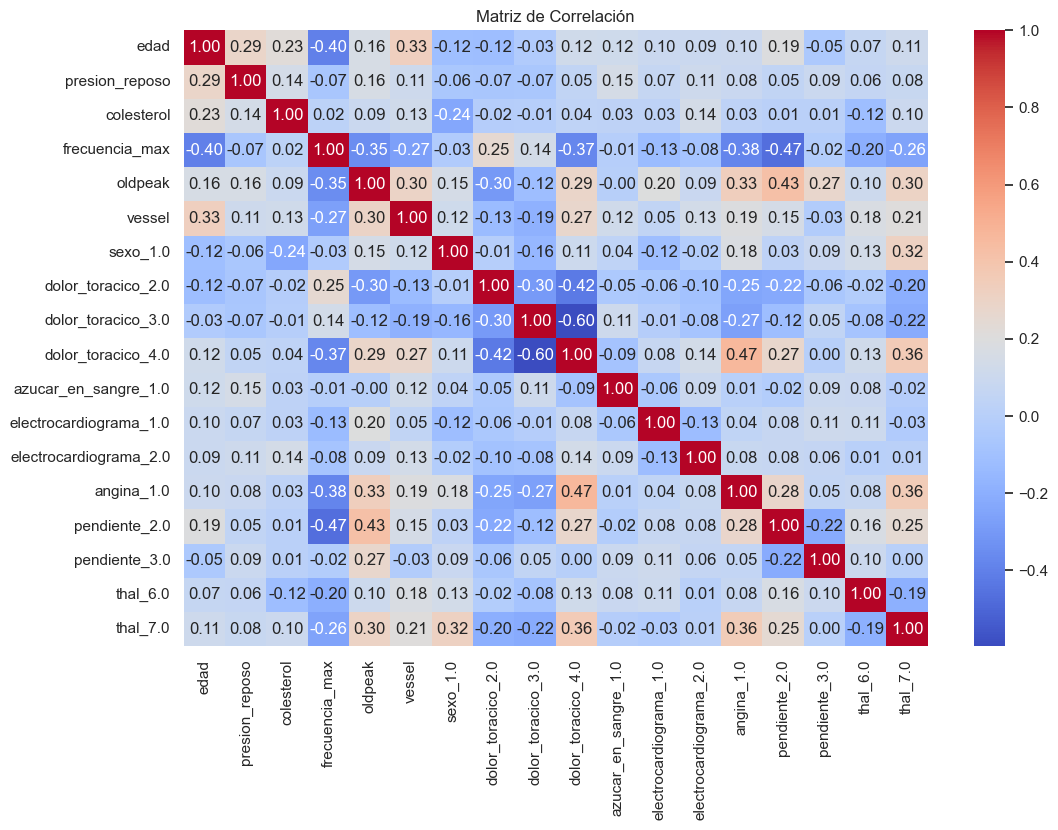

In [32]:
corr_matrix = df_processed.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

In [33]:
vif_data = pd.DataFrame()
vif_data["feature"] = df_processed.columns
vif_data["VIF"] = [variance_inflation_factor(df_processed.values, i)
                   for i in range(df_processed.shape[1])]


In [34]:
print(vif_data.sort_values("VIF", ascending=False))

                   feature       VIF
9       dolor_toracico_4.0  3.748691
6                 sexo_1.0  3.716035
14           pendiente_2.0  2.983808
17                thal_7.0  2.628663
13              angina_1.0  2.282748
12  electrocardiograma_2.0  2.038217
8       dolor_toracico_3.0  2.036162
4                  oldpeak  1.828869
7       dolor_toracico_2.0  1.743348
3           frecuencia_max  1.729784
0                     edad  1.488350
15           pendiente_3.0  1.437838
16                thal_6.0  1.387046
5                   vessel  1.362847
10    azucar_en_sangre_1.0  1.302738
2               colesterol  1.216721
1           presion_reposo  1.177601
11  electrocardiograma_1.0  1.133935


Podemos observar que ninguno de las variables tiene un VIF lo suficientemente alto para considerar eliminacion debido a multicolinealidad 

# Evaluacion del mejor modelo con crossvalidation

Se realiza una evaluacion con cross-validation para encontrar el mejor modelo

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [36]:
scores = cross_val_score(Pipe, X, Y, cv=cv)
print("Cross-validation scores:\n{}".format(scores))
print("Accuracy promedio:", np.mean(scores))

Cross-validation scores:
[0.85245902 0.73770492 0.8        0.88333333 0.7       ]
Accuracy promedio: 0.7946994535519126


# Evaluacion de metricas 

Se realizan la evaluacion de metricas para el modelo de GaussianNB

In [37]:
y_pred = Pipe.predict(X_test)

## Matriz de confusion y classification report 

In [38]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Confusion Matrix:
 [[27  6]
 [ 3 25]]


Podemos observar que la matriz de confusion es bastante equilibrada en cuanto a los errores 

In [39]:
print("Classification report:\n", classification_report(y_test, y_pred))

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.82      0.86        33
           1       0.81      0.89      0.85        28

    accuracy                           0.85        61
   macro avg       0.85      0.86      0.85        61
weighted avg       0.86      0.85      0.85        61



In [40]:
scores = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision ": precision_score(y_test, y_pred),
    "Recall ": recall_score(y_test, y_pred),
    "F1-score ": f1_score(y_test, y_pred)
}

scores_df = pd.DataFrame(scores, index=["Score"])
print("\nTabla de métricas globales:\n")
print(scores_df)


Tabla de métricas globales:

       Accuracy  Precision    Recall   F1-score 
Score  0.852459    0.806452  0.892857   0.847458


Podemos observar que el modelo tiene un accuracy del 0.85, en general podemos observar que el f1 score de ambos es relativamente similar con la clase de ausencia de enfermedad teniendo un poco mas, siendo esta clase predicha con mayor precision pero la clase 1 tiene mayor recall y es detectada de mejor manera 

## Curva ROC y AUC 

In [41]:
y_prob = Pipe.predict_proba(X_test)[:, 1]

AUC: 0.8777056277056278


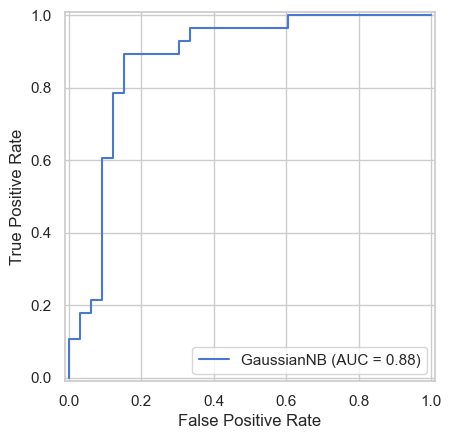

In [42]:
# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
print("AUC:", roc_auc)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name="GaussianNB").plot()
plt.show()

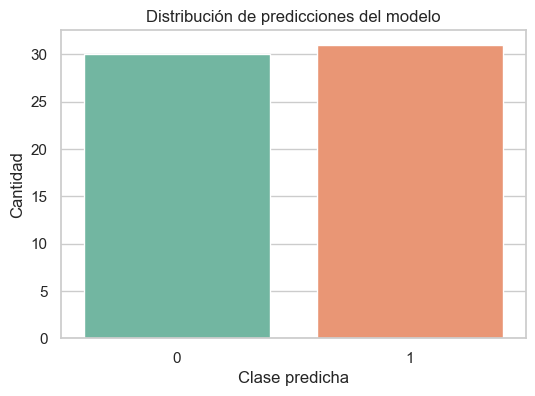

In [43]:
plt.figure(figsize=(6,4))
sns.countplot(x=y_pred, palette="Set2")
plt.title("Distribución de predicciones del modelo")
plt.xlabel("Clase predicha")
plt.ylabel("Cantidad")
plt.show()

Podemos analizar del grafico de distribucion de predicciones que el modelo predice ambas clases de manera bastante balanceada lo cual es consistente con los scores realizados anteriormente, podemos ver que hay una ligera preferencia a predecir la clase 1 pero no es lo suficientemente significativa como para alterar los resultados

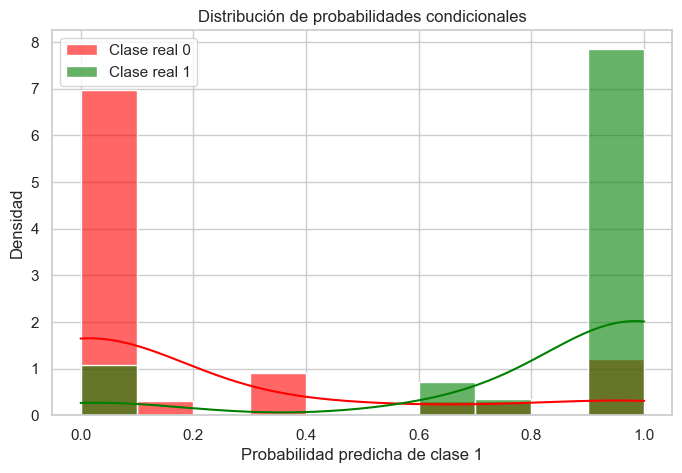

In [44]:
plt.figure(figsize=(8,5))
sns.histplot(y_prob[y_test==0], color="red", label="Clase real 0", kde=True, stat="density", bins=10, alpha=0.6)
sns.histplot(y_prob[y_test==1], color="green", label="Clase real 1", kde=True, stat="density", bins=10, alpha=0.6)
plt.title("Distribución de probabilidades condicionales")
plt.xlabel("Probabilidad predicha de clase 1")
plt.ylabel("Densidad")
plt.legend()
plt.show()

Podemos observar con el grafico de distribucion de probabilidades condicionales que el modelo realiza las predicciones de manera confiable y separada entre las 2 clases. Podemos observar que la mayoria de las predicciones de 0 se agrupan en 0 y las predicciones para la clase 1 se agrupan en 1, lo cual es ideal para este tipo de graficos

## Comparacion con el modelo logistico

Se realiza un Pipeline con el modelo de LogisticRegression para realizar una comparacion entre su desempeño

In [45]:
Pipe_log = Pipeline(steps=[("preprocesador", preprocesador),
                         ("model", LogisticRegression())])

In [46]:
Pipe_log.fit(X_train,y_train)

Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['edad', 'presion_reposo',
                                                   'colesterol',
                                                   'frecuencia_max', 'oldpeak',
                                                   'vessel']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['sexo', 'dolor_toracico',
                                                   'azucar_en_sangre',
                                                   'electrocardiograma',
                                                   'angina', 'pendiente',
                                                   'thal'])])),
                ('model', LogisticRegression())])

In [47]:
y_pred_lr = Pipe_log.predict(X_test)

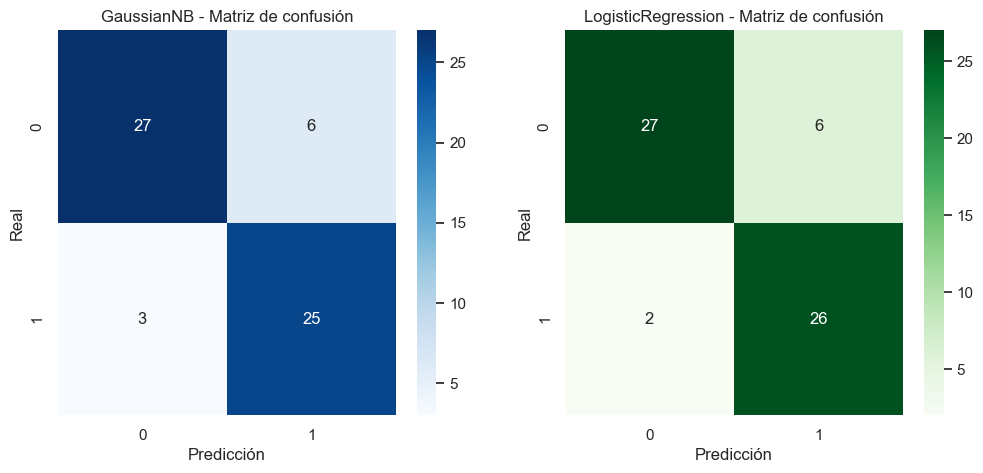

In [48]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("GaussianNB - Matriz de confusión")
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("LogisticRegression - Matriz de confusión")
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")

plt.show()

In [49]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [50]:
scores_lr = {
    "Accuracy": accuracy_score(y_test, y_pred_lr),
    "Precision ": precision_score(y_test, y_pred_lr),
    "Recall ": recall_score(y_test, y_pred_lr),
    "F1-score ": f1_score(y_test, y_pred_lr)
}

scores_df_lr = pd.DataFrame(scores_lr, index=["Score"])
print("\nTabla de métricas globales:\n")
print(scores_df_lr)


Tabla de métricas globales:

       Accuracy  Precision    Recall   F1-score 
Score  0.868852      0.8125  0.928571   0.866667


Podemos observar que tanto en la matriz de confusion y en el classification report los scores no cambian demasiado a comparacion de el modelo GaussianNB teniendo una ligera mejora en cuanto al modelo anterior

## Curva ROC logistico

In [51]:
y_prob_log = Pipe_log.predict_proba(X_test)[:, 1]

AUC: 0.922077922077922


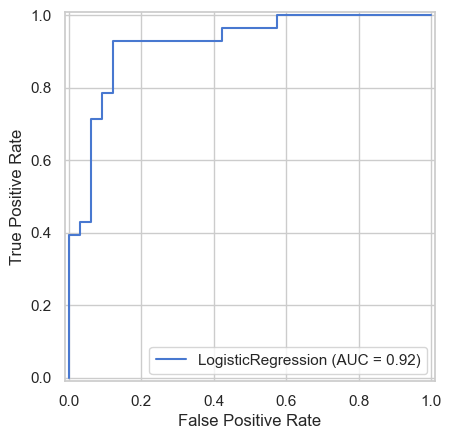

In [52]:
fpr_log, tpr_log, thresholds = roc_curve(y_test, y_prob_log)
roc_auc_log = auc(fpr_log, tpr_log)
print("AUC:", roc_auc_log)

RocCurveDisplay(fpr=fpr_log, tpr=tpr_log, roc_auc=roc_auc_log, estimator_name="LogisticRegression").plot()
plt.show()

Podemos observar que el AUC del logistic Regression es ligeramente mayor al del GaussianNB, por lo que combinado con los scores anteriores se concluye que el modelo de LogisticRegression es bastante robusto y es mas adecuado para este analisis

# Analisis critico y Conclusiones

## Analisis de importancia de variables 

In [53]:
modelo = Pipe.named_steps["modelo"]

print("Medias por clase:\n", modelo.theta_)
print("Varianzas por clase:\n", modelo.var_)

Medias por clase:
 [[-0.20616994 -0.16901346 -0.05937811  0.38301381 -0.3955583  -0.42809021
   0.55384615  0.26153846  0.43846154  0.21538462  0.15384615  0.00769231
   0.40769231  0.16923077  0.27692308  0.05384615  0.02307692  0.16153846]
 [ 0.24146029  0.1979437   0.06954193 -0.44857473  0.46326648  0.50136691
   0.81981982  0.07207207  0.12612613  0.74774775  0.17117117  0.02702703
   0.57657658  0.56756757  0.66666667  0.05405405  0.0990991   0.63063063]]
Varianzas por clase:
 [[1.13253913 0.85466981 1.06430736 0.68700326 0.47625333 0.43365356
  0.24710059 0.1931361  0.24621302 0.16899408 0.13017752 0.00763314
  0.24147929 0.14059172 0.20023669 0.05094675 0.02254438 0.13544379]
 [0.73668906 1.09756967 0.91571972 0.99354315 1.21553227 1.19728959
  0.14771528 0.06687769 0.11021833 0.18862105 0.1418716  0.02629657
  0.24413603 0.24543462 0.22222222 0.05113221 0.08927847 0.23293564]]


In [54]:
means = modelo.theta_
vars_ = modelo.var_ 
separacion = np.abs(means[0] - means[1]) / np.sqrt(vars_[0] + vars_[1])

In [55]:
feature_importance_nb = pd.DataFrame({
    "feature": all_features,
    "separacion": separacion
}).sort_values("separacion", ascending=False)

print(feature_importance_nb)

                   feature  separacion
9       dolor_toracico_4.0    0.890225
17                thal_7.0    0.772877
5                   vessel    0.727796
4                  oldpeak    0.660286
3           frecuencia_max    0.641480
13              angina_1.0    0.641124
14           pendiente_2.0    0.599635
8       dolor_toracico_3.0    0.523158
6                 sexo_1.0    0.423293
7       dolor_toracico_2.0    0.371564
0                     edad    0.327407
1           presion_reposo    0.262633
12  electrocardiograma_2.0    0.242350
16                thal_6.0    0.227340
11  electrocardiograma_1.0    0.104966
2               colesterol    0.091619
10    azucar_en_sangre_1.0    0.033216
15           pendiente_3.0    0.000651


<Figure size 1000x600 with 0 Axes>

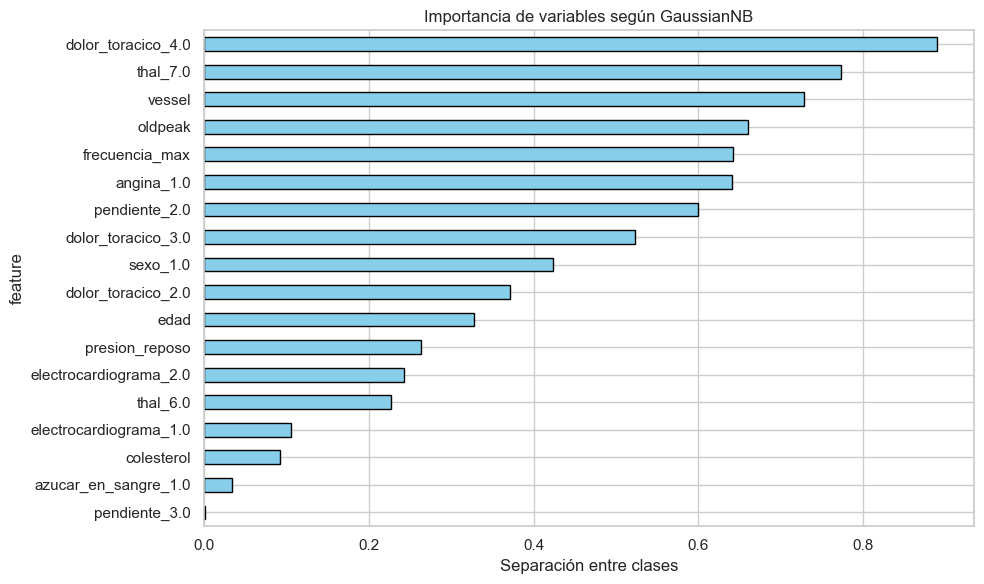

In [56]:
plt.figure(figsize=(10,6))
feature_importance_nb.sort_values("separacion", ascending=True).plot(
    x="feature", y="separacion", kind="barh", legend=False, figsize=(10,6),
    color="skyblue", edgecolor="black"
)
plt.xlabel("Separación entre clases")
plt.title("Importancia de variables según GaussianNB")
plt.tight_layout()
plt.show()

Se utiliza una formula de discriminacion estadistica para estimar cuanto contribuye cada variable con la separacion de clases y cual influye mas para distinguir entre clases 

Podemos observar que las variables que mas influyen son dolor toracico asimptomatico, thal con defecto reversible,vessel,oldpeak y la frecuencia maxima de latidos 

## Analisis de modelo de Bayes 

El modelo Naive Bayes Gaussiano mostró un desempeño general sólido, con una accuracy del 85%, y un balance aceptable entre precision y recall para ambas clases (enfermo y no enfermo). Esto resalta una de sus principales fortalezas: es simple, rápido de entrenar y eficiente, incluso con un conjunto de datos relativamente pequeño. 

Sin embargo su desempeño tambien se ve influenciado por su principal limitacion: La asuncion de independencia condicional entre variables. En el contexto dado algunas de las variables estan correlacionadas por lo que no se cumple esta suposicion. Al ser comparado con otro clasificador como el LogisticRegression se vio que ambos tenian socres similares pero Logistic era mas robusto en general. 
El modelo de GaussianNB en general pudo lograr capturar patrones relevantes y tener scores moderadamente altos, por lo que en este contexto no afecta demasiado que no se cumpla este supuesto como si lo haria en un dataset mas complejo que este. 

## Reflexion en el ambito medico

El modelo de bayes, , al ser un algoritmo estadístico simple y fácilmente interpretable, presenta una ventaja considerable en el ámbito médico, donde la transparencia en la toma de decisiones es crucial. 

La interpretabilidad del modelo permite que los profesionales de la salud comprendan el peso que tiene cada variable en la predicción, lo cual es clave para generar confianza en el uso del modelo como apoyo clínico. A diferencia de modelos más complejos, el modelo de Bayes puede justificar sus predicciones de manera más transparente, lo que facilita su adopción en entornos donde las decisiones tienen implicaciones éticas y legales.

No obstante, su aplicabilidad médica puede verse limitada por su principal suposición: la independencia condicional entre variables. En la práctica médica, muchas variables (síntomas, antecedentes, resultados de laboratorio) están fuertemente correlacionadas. Esta violación del supuesto puede comprometer la precisión del modelo en contextos más complejos o con alta interdependencia entre características clínicas.

Aun asi, el modelo puede ofrecer resultados útiles y eficientes para tomar decisiones preliminares o priorizar pacientes para evaluación adicional.